###**Setup**:

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

###**Load** **Data** **File**:

In [84]:
df = pd.read_csv('advertising.csv')
print('Shape:', df.shape)

Shape: (200, 4)


In [85]:
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


###ploting:

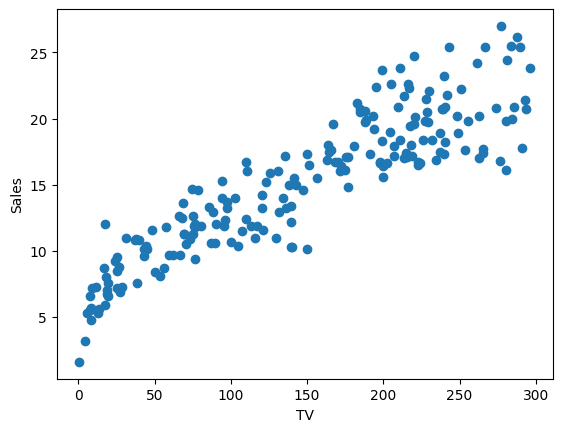

In [86]:
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

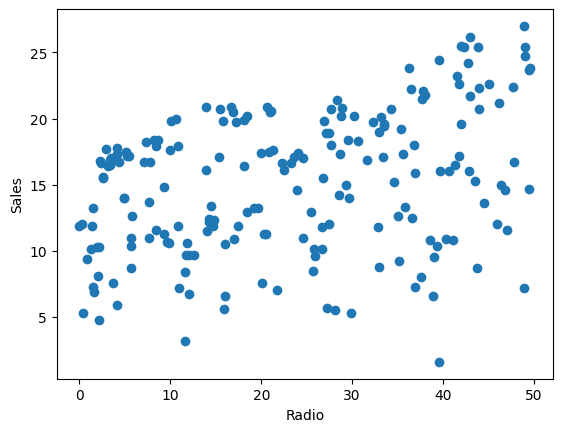

In [87]:
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.show()

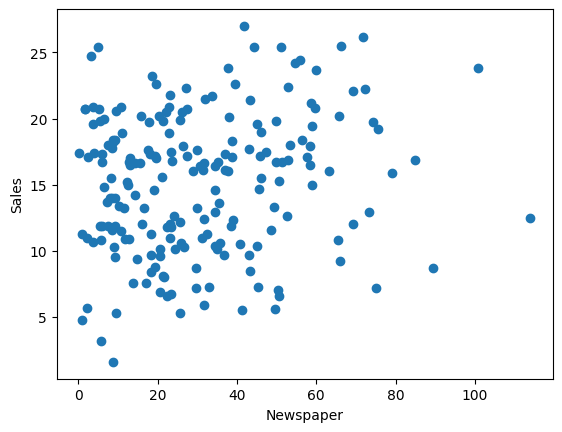

In [88]:
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.show()

---
# Part 1 — Simple Linear Regression

One input feature → predict `Sales`.

We start with `TV` — it has the clearest linear relationship.

$$\hat{y} = w_0 + w_1 \cdot \text{TV}$$

In [89]:
x=df[['TV']]
y=df['Sales']


x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.2,random_state=42)
#number of instances
print(f'Train: {len(x_tr)} rows  |  Test: {len(x_te)} rows')

Train: 160 rows  |  Test: 40 rows


In [90]:
model1 = LinearRegression()
model1.fit(x_tr, y_tr)
print (f'w0 = {model1.intercept_}')#intercept
print (f'w1 = {model1.coef_[0]}')#coef1

w0 = 7.007108428241848
w1 = 0.0554829439314632


In [91]:
y_pred1 = model1.predict(x_te)
Rmse = np.sqrt(mean_squared_error(y_te, y_pred1))
r2   = r2_score(y_te, y_pred1)
r2   = model1.score(x_te,y_te)
print(f'RMSE : ${Rmse:,.0f}')
print(f'R²   : {r2:.4f}')

RMSE : $2
R²   : 0.8026


####Ploting Simple LR:

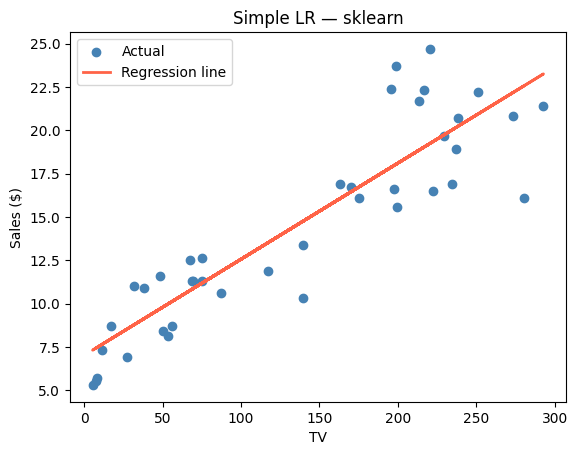

In [92]:
plt.scatter(x_te , y_te , color='steelblue', label='Actual')
plt.plot(x_te , y_pred1 , color='tomato', lw=2, label='Regression line')
plt.xlabel('TV')
plt.ylabel('Sales ($)')
plt.title('Simple LR — sklearn')
plt.legend()
plt.show()

---
# Part 2 — Multiple Linear Regression

Now we use **both features** together — `YearsExperience` and `Age`:

$$\hat{y} = w_0 + w_1 \cdot \text{YearsExperience} + w_2 \cdot \text{Age}$$

####Multible LR for Data Fille sales Target:

In [93]:
x_multi=df[['TV','Radio','Newspaper']]
y_multi=df['Sales']


x_tr_m,x_te_m,y_tr_m,y_te_m=train_test_split(x_multi,y_multi,test_size=0.2,random_state=42)
#number of instances
print(f'Train: {len(x_tr_m)} rows  |  Test: {len(x_te_m)} rows')

Train: 160 rows  |  Test: 40 rows


In [94]:
model = LinearRegression()
model.fit(x_tr_m, y_tr_m)
print (f'w0 = {model.intercept_}')#intercept
print (f'w1 = {model.coef_[0]}')#coef1
print (f'w2 = {model.coef_[1]}')#coef2
print(f'w3 = {model.coef_[2]}')#coef3

w0 = 4.714126402214127
w1 = 0.05450927083721978
w2 = 0.10094536239295579
w3 = 0.0043366468220340446


In [95]:

y_pred = model.predict(x_te_m)
rmse = np.sqrt(mean_squared_error(y_te_m, y_pred))
r2_m   = r2_score(y_te_m, y_pred)
print(f'RMSE : ${rmse:,.0f}')
print(f'R²   : {r2_m:.4f}')
print(f'Simple LR R²: {r2:.4f}  →  Multiple LR R²: {r2_m:.4f}')

RMSE : $2
R²   : 0.9059
Simple LR R²: 0.8026  →  Multiple LR R²: 0.9059


####Ploting Multiple LR:

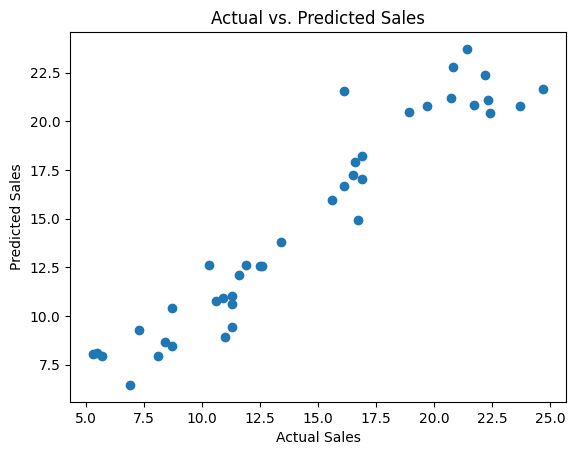

In [96]:
plt.scatter(y_te_m, y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales')
plt.show()